In [97]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [98]:
import matplotlib.pyplot as plt

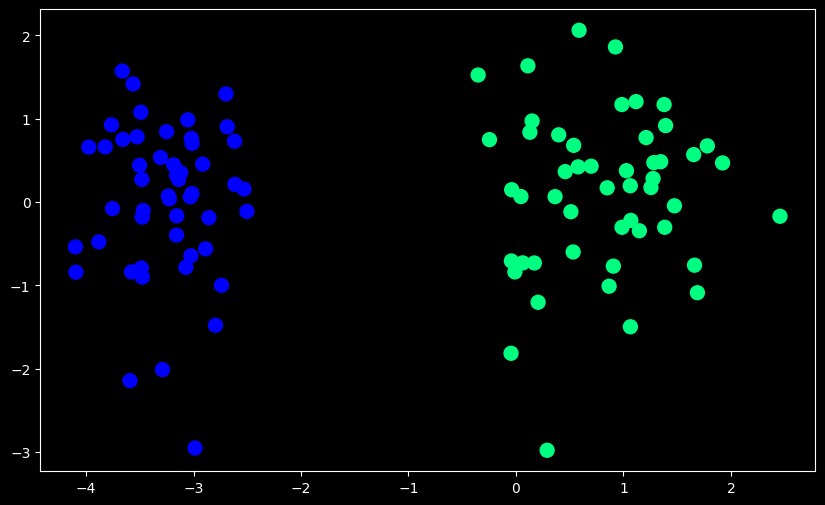

In [99]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)

In [114]:
def gd(X, y):
    X =  np.insert(X, 0, 1, axis=1)
    n_samples, n_features = X.shape
    W = np.zeros(n_features)
    lr = 0.5
    epochs = 5000
    # print(W.shape)

    def sigmoid(z):
        return 1 / (1 + np.exp(-z))

    for i in range(epochs):
        y_pred = sigmoid(X @ W.T)
        error = y - y_pred
        # print(error.shape)
        W += (lr /n_samples) * error.T @ X

    return W[0], W[1:]


In [115]:
intercept_, coef_ = gd(X, y)

In [116]:
intercept_, coef_

(np.float64(5.828740081963282), array([4.83593014, 0.21130576]))

In [117]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [118]:
m, b

(np.float64(-22.885936084650385), np.float64(-27.584387918449007))

In [119]:
x_input = np.linspace(-3, 3, 100)
y_input = m*x_input + b

(-3.0, 2.0)

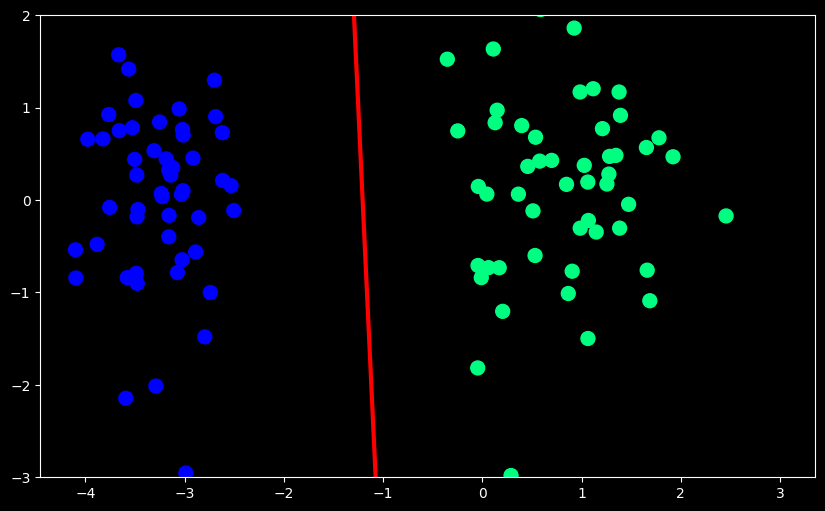

In [120]:
plt.figure(figsize=(10, 6))
plt.plot(x_input, y_input, color = 'red', linewidth = 3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
plt.ylim(-3,2)

In [121]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)


/home/batman/maskedsyntax/x-from-scratch-ml/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [122]:
m1 = -(lor.coef_[0][0]/lor.coef_[0][1])
b1 = -(lor.intercept_/lor.coef_[0][1])

In [123]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m1*x_input + b1

(-3.0, 2.0)

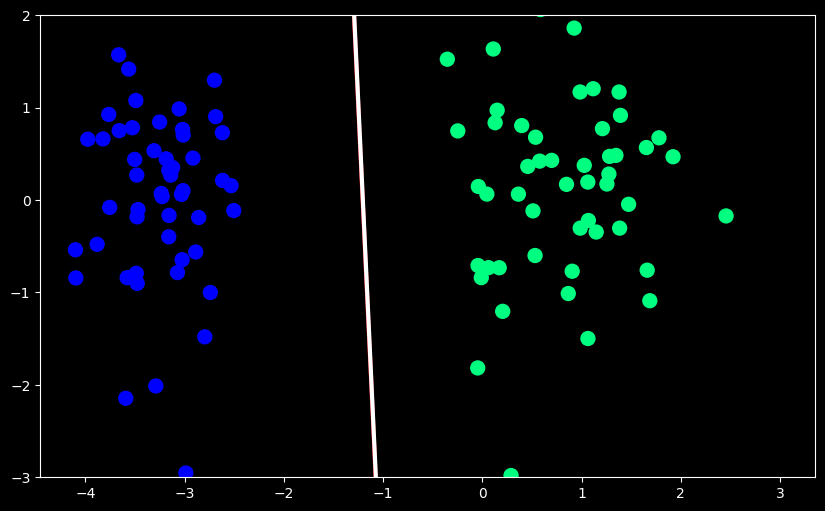

In [124]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='white',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)